## Prepare Data for Explanations



In [ ]:
X_explain = X_selected.copy()
y_explain = y_encoded.copy()

print(f"Shape of X_explain: {X_explain.shape}")
print(f"Shape of y_explain: {y_explain.shape}")

Shape of X_explain: (4424, 50)
Shape of y_explain: (4424,)


## Calculate SHAP Values


In [ ]:
import shap

# Load the best_random_forest_model if not already in memory
# import joblib
# best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Initialize a SHAP TreeExplainer with the best Random Forest model
explainer = shap.TreeExplainer(best_random_forest_model)

# Calculate SHAP values for X_explain
shap_values = explainer.shap_values(X_explain)

print("SHAP explainer initialized and SHAP values calculated.")
# The shap_values will be a list of arrays for multi-output models, or a single array for single-output.
# For multi-class classification (as indicated by LabelEncoder with 3 classes), shap_values will be a list of 3 arrays.
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of outputs (classes) in shap_values: {len(shap_values)}")
    print(f"Shape of SHAP values for the first class: {shap_values[0].shape}")
else:
    print(f"Shape of SHAP values: {shap_values.shape}")

SHAP explainer initialized and SHAP values calculated.
Type of shap_values: <class 'numpy.ndarray'>
Shape of SHAP values: (4424, 50, 3)


Generating SHAP summary plot for all classes...


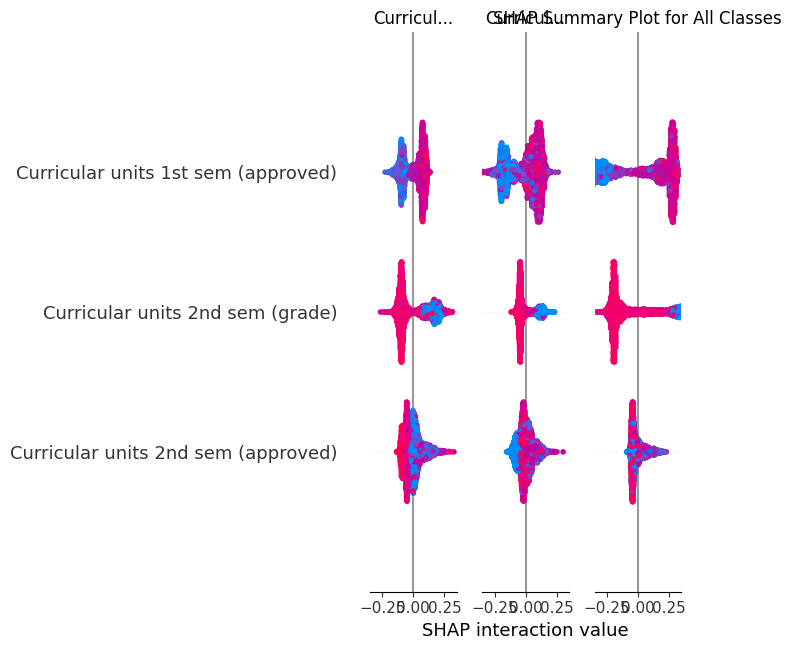

SHAP summary plot generated.


In [ ]:
import matplotlib.pyplot as plt

# Assuming shap_values is a list of arrays (one for each class)
# For multi-class, shap.summary_plot can take a list of shap_values

print("Generating SHAP summary plot for all classes...")
# Create a mapping from encoded labels back to original class names
class_names = le.inverse_transform([0, 1, 2]) # Assuming 0, 1, 2 are the encoded classes

shap.summary_plot(shap_values, X_explain, class_names=class_names, show=False)
plt.title('SHAP Summary Plot for All Classes')
plt.tight_layout()
plt.show()

print("SHAP summary plot generated.")

Generating SHAP dependence plots for the top 3 features...


<Figure size 1000x600 with 0 Axes>

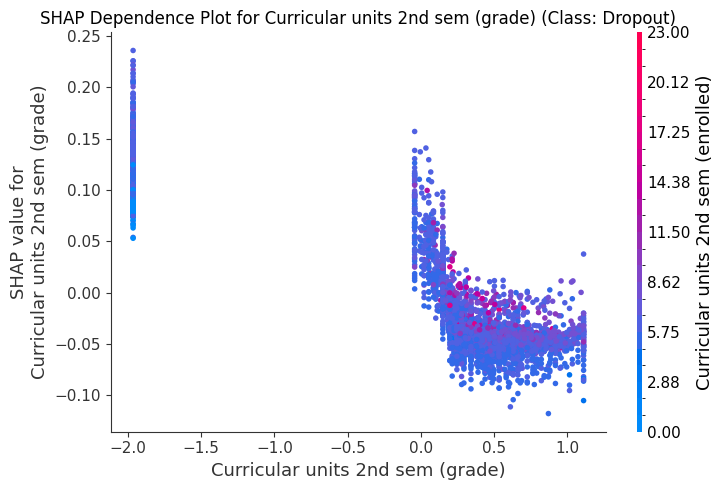

<Figure size 1000x600 with 0 Axes>

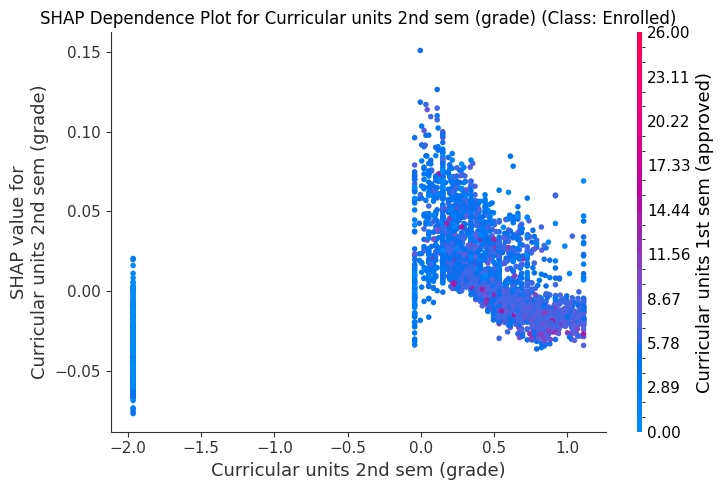

<Figure size 1000x600 with 0 Axes>

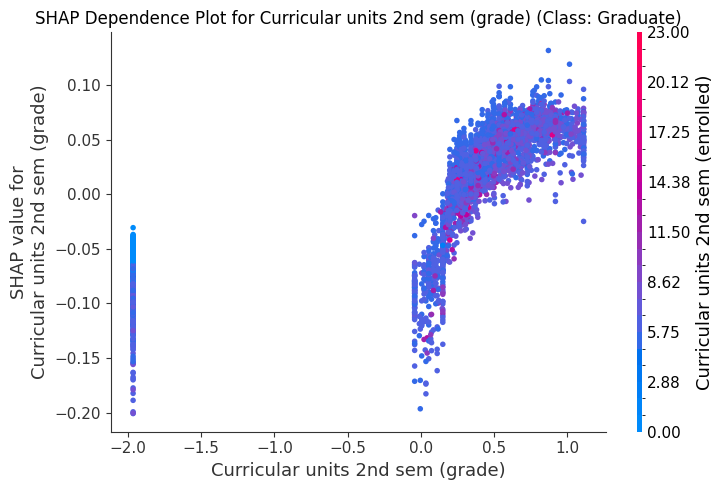

<Figure size 1000x600 with 0 Axes>

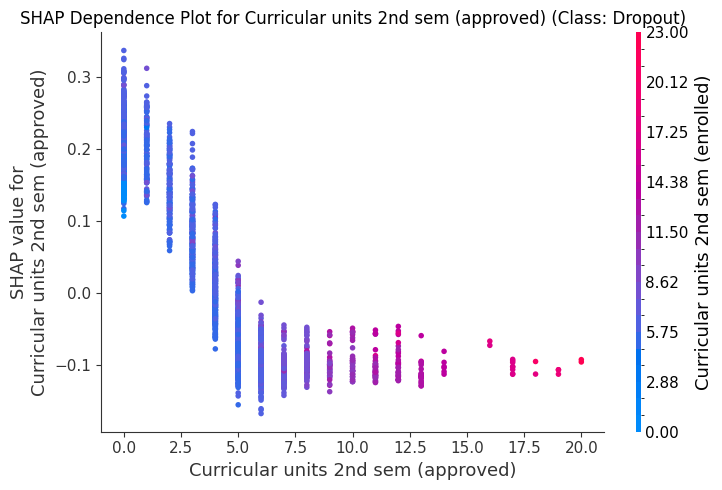

<Figure size 1000x600 with 0 Axes>

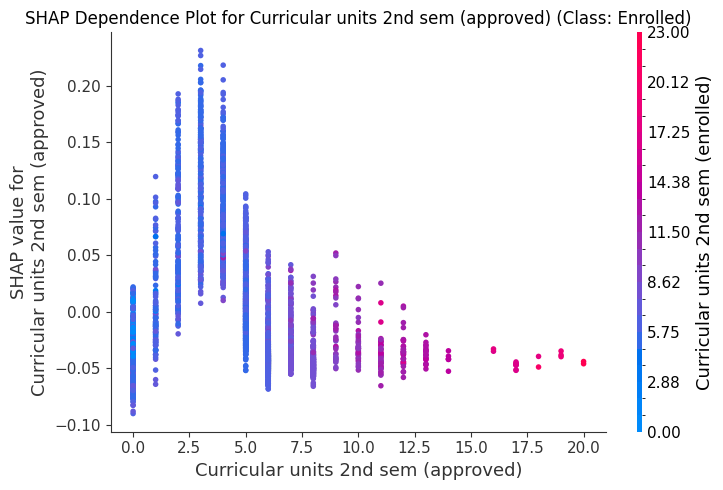

<Figure size 1000x600 with 0 Axes>

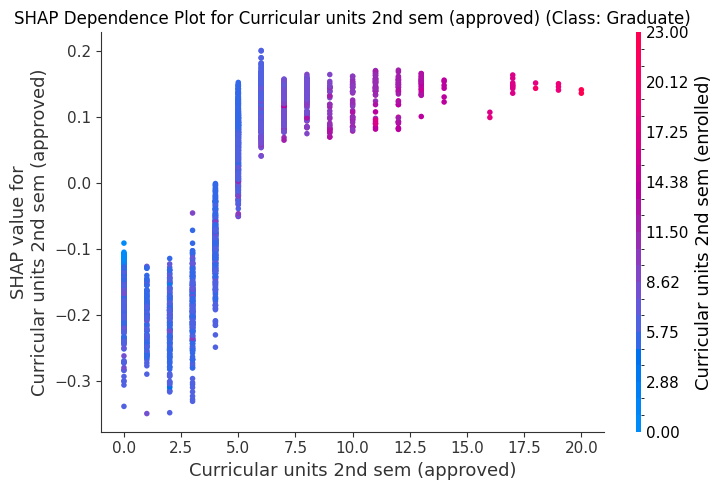

<Figure size 1000x600 with 0 Axes>

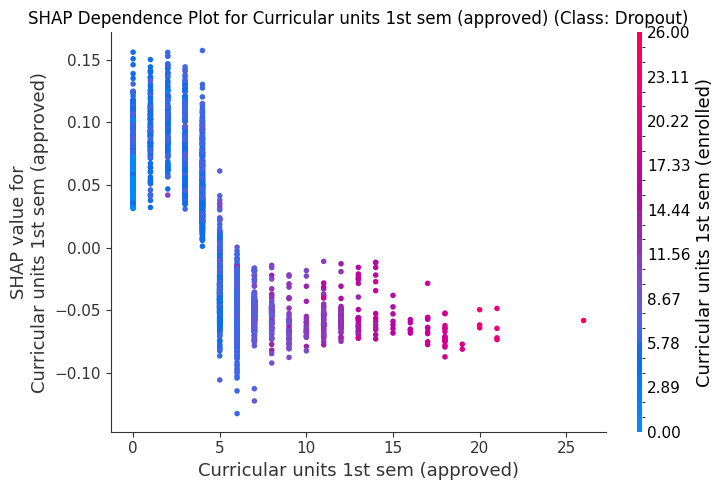

<Figure size 1000x600 with 0 Axes>

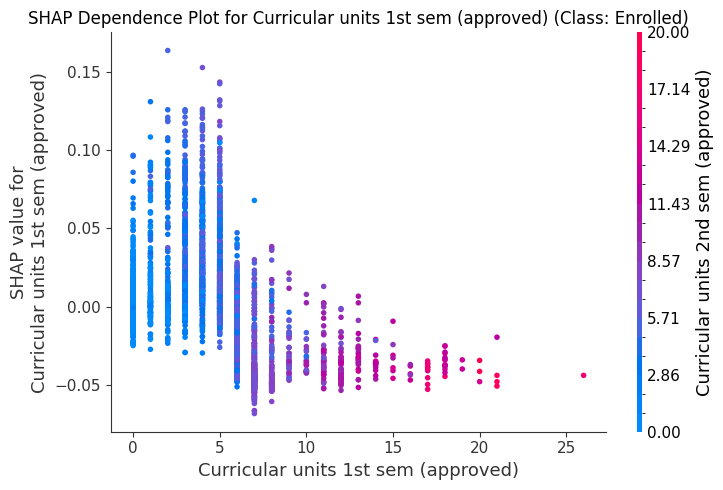

<Figure size 1000x600 with 0 Axes>

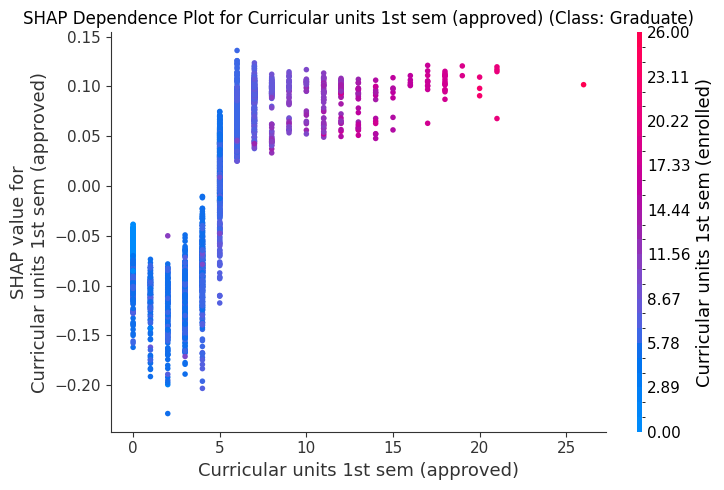

SHAP dependence plots generated.


In [ ]:
import matplotlib.pyplot as plt

# Select the top N features for dependence plots
n_dependence_features = 3
top_dependence_features = feature_importances['feature'].head(n_dependence_features).tolist()

print(f"Generating SHAP dependence plots for the top {n_dependence_features} features...")

# Iterate through each selected feature
for feature in top_dependence_features:
    # Get the index of the feature in X_explain's columns
    # feature_idx = X_explain.columns.get_loc(feature) # Not strictly needed for dependence_plot if 'feature' string is passed

    # Generate dependence plot for each class
    for i, class_name in enumerate(class_names):
        plt.figure(figsize=(10, 6))
        # shap_values is a list of arrays for multi-class, where each element is for a class.
        # So, shap_values[i] gives SHAP values for class 'i'
        shap.dependence_plot(
            ind=feature,
            shap_values=shap_values[:, :, i], # Select SHAP values for the current class (i)
            features=X_explain,
            # interaction_index=None, # Automatically finds best interaction feature
            # or specify an interaction feature if desired, e.g., interaction_index='Age at enrollment'
            show=False # Suppress auto-display to allow custom titles
        )
        plt.title(f'SHAP Dependence Plot for {feature} (Class: {class_name})')
        plt.tight_layout()
        plt.show()

print("SHAP dependence plots generated.")

## Generate Partial Dependence Plots (PDPs)


Generating Partial Dependence Plots for key numerical features...


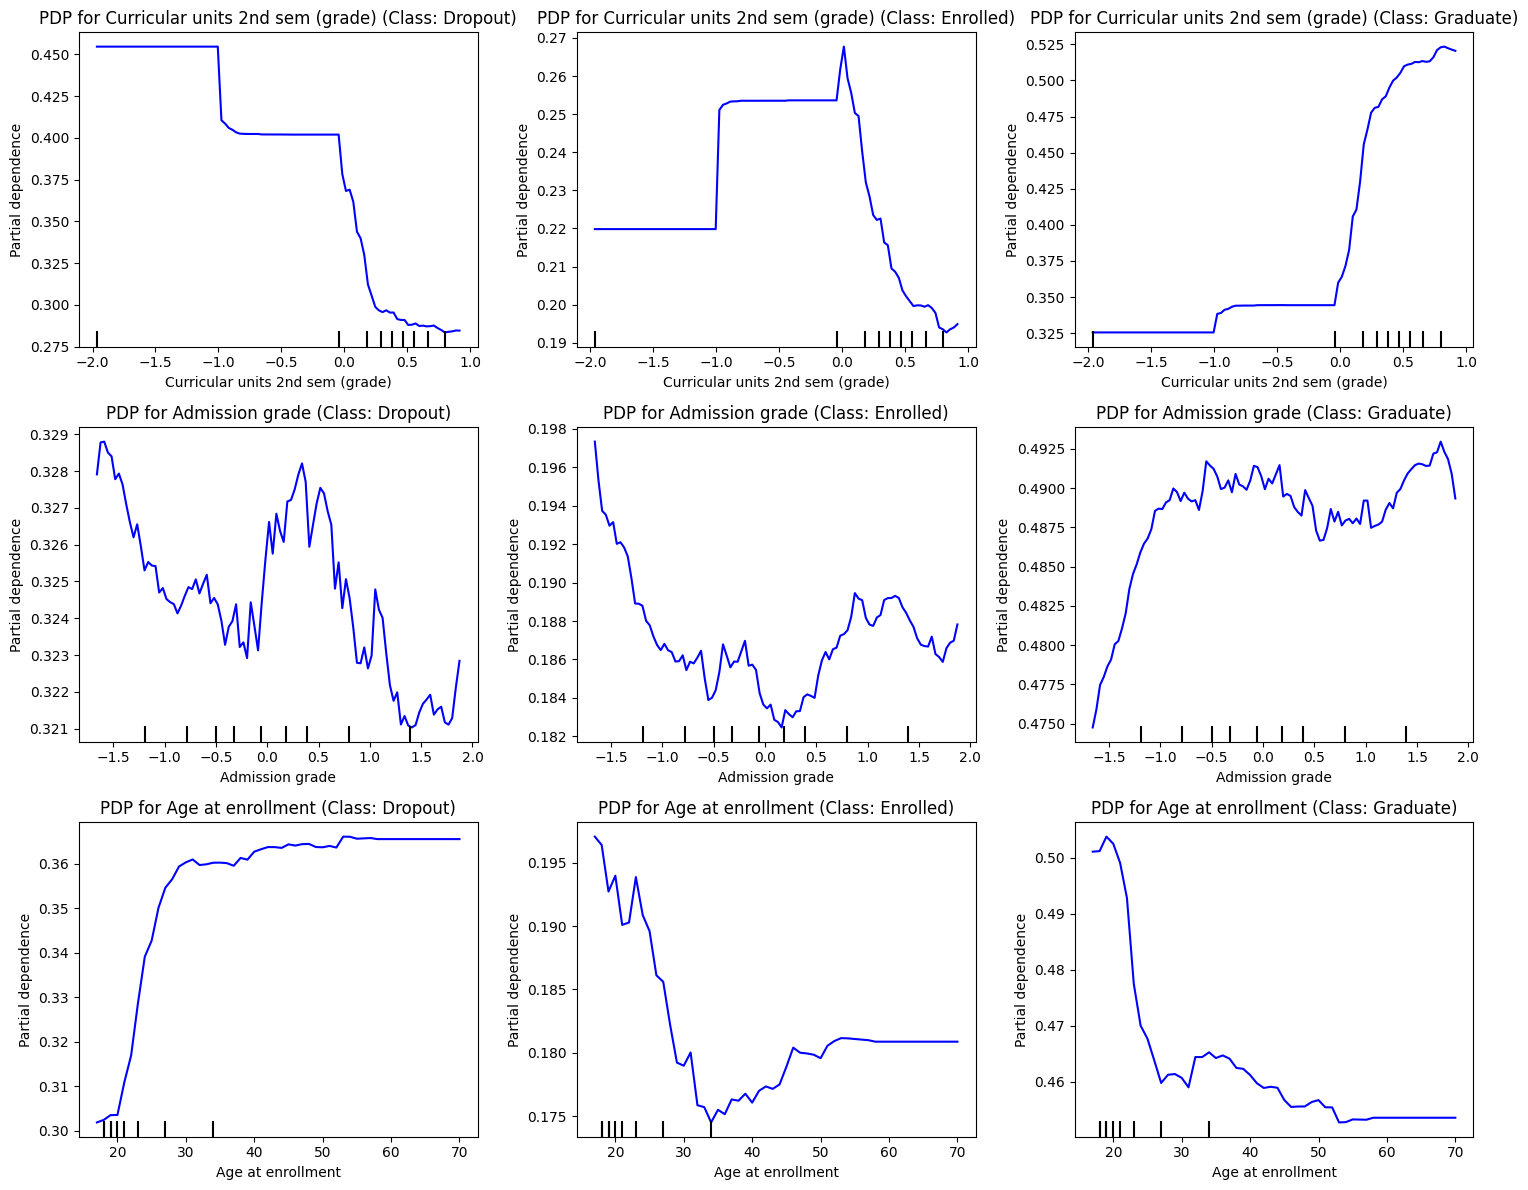

Partial Dependence Plots generated successfully.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Ensure `best_random_forest_model` and `X_selected` (or `X_explain`) are available from previous steps
# Also ensure `class_names` and `le` are available.

print("Generating Partial Dependence Plots for key numerical features...")

# Define the key features for PDP as specified in the subtask
key_features_for_pdp = ['Curricular units 2nd sem (grade)', 'Admission grade', 'Age at enrollment']

# Prepare the data and model for PDP
model = best_random_forest_model
features = X_selected # Use X_selected which contains the top features from training

# Create a figure for all PDPs
n_features = len(key_features_for_pdp)
n_classes = len(class_names)

# Set up subplots dynamically
fig, axes = plt.subplots(n_features, n_classes, figsize=(5 * n_classes, 4 * n_features), squeeze=False)

for i, feature_name in enumerate(key_features_for_pdp):
    for j, class_label in enumerate(class_names):
        # PartialDependenceDisplay requires a feature to be specified by its name or index
        # For multi-class, it generates one plot per class automatically if target_class is not specified.
        # To get separate plots per class as per instruction, we specify target_class.

        # Create a single plot for the current feature and target class
        display = PartialDependenceDisplay.from_estimator(
            estimator=model,
            X=features,
            features=[feature_name],
            target=j, # Specify the target class (0, 1, 2 for 'Dropout', 'Enrolled', 'Graduate')
            ax=axes[i, j],
            line_kw={'color': 'blue'}
        )
        axes[i, j].set_title(f'PDP for {feature_name} (Class: {class_label})')
        axes[i, j].set_xlabel(feature_name)
        axes[i, j].set_ylabel('Partial Dependence')

plt.tight_layout()
plt.show()

print("Partial Dependence Plots generated successfully.")

## Generate Individual Conditional Expectation (ICE) Plots


Generating Individual Conditional Expectation (ICE) Plots for key numerical features...


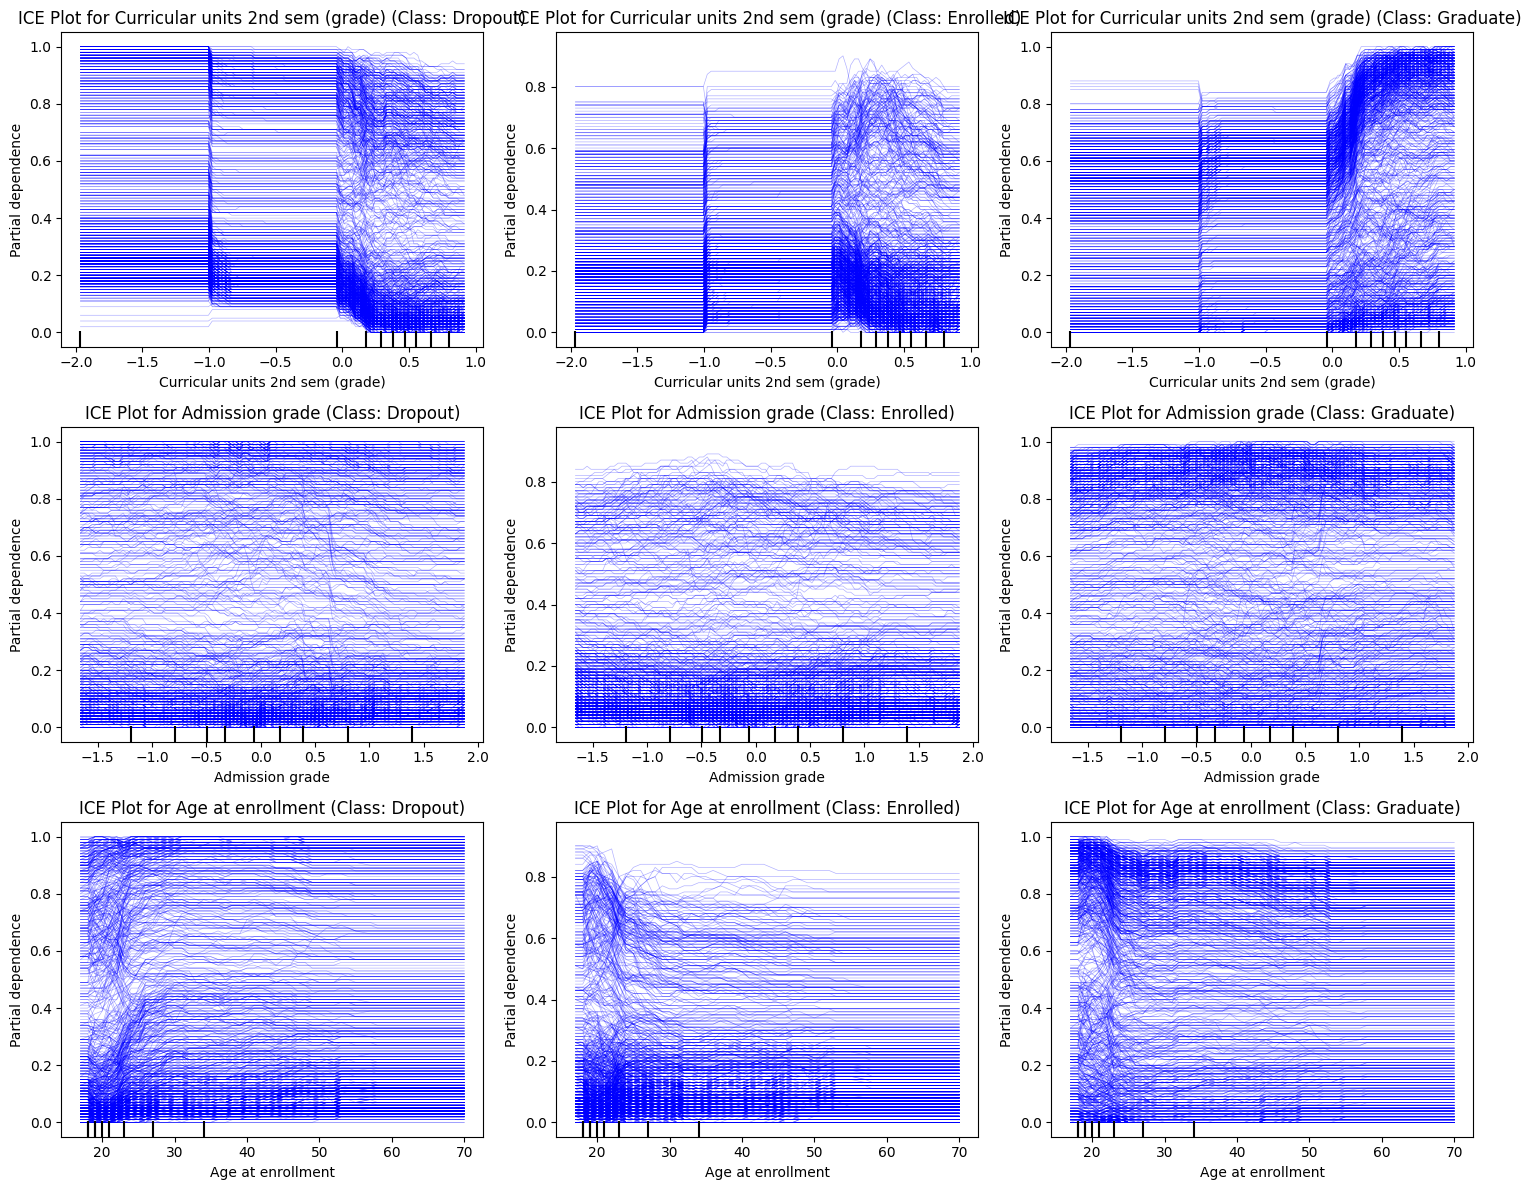

Individual Conditional Expectation (ICE) Plots generated successfully.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Ensure `best_random_forest_model`, `X_selected` (or `X_explain`), and `class_names` are available

print("Generating Individual Conditional Expectation (ICE) Plots for key numerical features...")

# Define the key features for ICE as specified in the subtask
key_features_for_ice = ['Curricular units 2nd sem (grade)', 'Admission grade', 'Age at enrollment']

# Prepare the data and model for ICE
model = best_random_forest_model
features = X_selected # Use X_selected which contains the top features from training

# Create a figure for all ICE plots
n_features = len(key_features_for_ice)
n_classes = len(class_names)

# Set up subplots dynamically
fig, axes = plt.subplots(n_features, n_classes, figsize=(5 * n_classes, 4 * n_features), squeeze=False)

for i, feature_name in enumerate(key_features_for_ice):
    for j, class_label in enumerate(class_names):
        # Create a single plot for the current feature and target class
        PartialDependenceDisplay.from_estimator(
            estimator=model,
            X=features,
            features=[feature_name],
            target=j, # Specify the target class (0, 1, 2 for 'Dropout', 'Enrolled', 'Graduate')
            kind='individual', # This specifies that we want ICE plots
            ax=axes[i, j],
            line_kw={'color': 'blue', 'alpha': 0.3} # Alpha for individual lines
        )
        axes[i, j].set_title(f'ICE Plot for {feature_name} (Class: {class_label})')
        axes[i, j].set_xlabel(feature_name)
        axes[i, j].set_ylabel('Individual Prediction')

plt.tight_layout()
plt.show()

print("Individual Conditional Expectation (ICE) Plots generated successfully.")

In [ ]:
pip install lime

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np # Import numpy for np.where

# Initialize LimeTabularExplainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=class_names,
    mode='classification'
)

print("LimeTabularExplainer initialized.")

# Select diverse instances for explanation
# Find an index for each class from the X_explain set using np.where
# le.transform(['Class Name'])[0] returns the numerical representation of the class
instance_dropout_idx = np.where(y_explain == le.transform(['Dropout'])[0])[0][0]
instance_enrolled_idx = np.where(y_explain == le.transform(['Enrolled'])[0])[0][0]
instance_graduate_idx = np.where(y_explain == le.transform(['Graduate'])[0])[0][0]

# Select the instances from X_explain using iloc since X_explain is a DataFrame
instance_dropout = X_explain.iloc[instance_dropout_idx]
instance_enrolled = X_explain.iloc[instance_enrolled_idx]
instance_graduate = X_explain.iloc[instance_graduate_idx]

print("Selected instances for explanation:")
print(f"  - Dropout instance shape: {instance_dropout.shape}")
print(f"  - Enrolled instance shape: {instance_enrolled.shape}")
print(f"  - Graduate instance shape: {instance_graduate.shape}")

print("Selected specific instances from each class for LIME explanations.")

LimeTabularExplainer initialized.
Selected instances for explanation:
  - Dropout instance shape: (50,)
  - Enrolled instance shape: (50,)
  - Graduate instance shape: (50,)
Selected specific instances from each class for LIME explanations.


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
# This ensures the predict_proba method is available to LIME
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Dropout instance
explanation_dropout = explainer_lime.explain_instance(
    data_row=instance_dropout.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_dropout = 'lime_explanation_dropout.html'
explanation_dropout.save_to_file(filename_dropout)

print(f"LIME explanation for 'Dropout' instance saved to {filename_dropout}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for 'Dropout' instance saved to lime_explanation_dropout.html


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
# This ensures the predict_proba method is available to LIME
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Dropout instance
explanation_dropout = explainer_lime.explain_instance(
    data_row=instance_dropout.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_dropout = 'lime_explanation_dropout.html'
explanation_dropout.save_to_file(filename_dropout)

print(f"LIME explanation for 'Dropout' instance saved to {filename_dropout}")

# Generate explanation for the Enrolled instance
explanation_enrolled = explainer_lime.explain_instance(
    data_row=instance_enrolled.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_enrolled = 'lime_explanation_enrolled.html'
explanation_enrolled.save_to_file(filename_enrolled)

print(f"LIME explanation for 'Enrolled' instance saved to {filename_enrolled}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for 'Dropout' instance saved to lime_explanation_dropout.html
LIME explanation for 'Enrolled' instance saved to lime_explanation_enrolled.html


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Graduate instance
explanation_graduate = explainer_lime.explain_instance(
    data_row=instance_graduate.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_graduate = 'lime_explanation_graduate.html'
explanation_graduate.save_to_file(filename_graduate)

print(f"LIME explanation for 'Graduate' instance saved to {filename_graduate}")

LIME explanation for 'Graduate' instance saved to lime_explanation_graduate.html


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib # Import joblib to load the model

# Load the best_random_forest_model if not already in memory
# This ensures the predict_proba method is available to LIME
best_random_forest_model = joblib.load('best_random_forest_model.joblib')

# Generate explanation for the Graduate instance
explanation_graduate = explainer_lime.explain_instance(
    data_row=instance_graduate.values,
    predict_fn=best_random_forest_model.predict_proba,
    num_features=10 # Explain using the top 10 features
)

# Save the explanation as an HTML file
filename_graduate = 'lime_explanation_graduate.html'
explanation_graduate.save_to_file(filename_graduate)

print(f"LIME explanation for 'Graduate' instance saved to {filename_graduate}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for 'Graduate' instance saved to lime_explanation_graduate.html
